In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
from matplotlib.gridspec import GridSpec
print(f'pyLabDD version {dd.__version__}')

# plot function for stress and pile-up dislocations
def plot_stress_bfield(npt = 300, file=None, cutoff=100., fs=(12, 9)):
    xmid = dsl.lx*0.5
    xpts = np.linspace(0.0, dsl.lx, npt) - xmid
    ypts = np.linspace(0.0, dsl.ly, npt)
    XP, YP = np.meshgrid(xpts, ypts)
    s12 = np.zeros((npt, npt), dtype=np.float64)
    for i in range(dsl.Ntot):
        s12 += dsl.bx[i] * dsl.sig_xy(XP - dsl.xpos[i] + xmid, YP - dsl.ypos[i])
        s12 -= dsl.by[i] * dsl.sig_xy(YP - dsl.ypos[i], XP - dsl.xpos[i] + xmid)
    extent = (-xmid, xmid, 0.0, dsl.ly)
    
    #fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 12), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)
    fig = plt.figure(figsize=fs)
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.0)
    # -----------------------------
    # upper plot: stress field and dislocations
    # -----------------------------
    ax1 = fig.add_subplot(gs[0])
    #ax1.xaxis.set_label_position('top')
    #ax1.set_xlabel(r"x ($\mu$m)")
    ax1.xaxis.tick_top()
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_ylabel(r"y ($\mu$m)")
    im = ax1.imshow(s12, origin="lower", extent=extent,
        vmin=-cutoff, vmax=cutoff, cmap=plt.cm.RdBu, aspect="equal")
    ax1.scatter(dsl.xpos[:npu] - xmid, dsl.ypos[:npu], s=10, c="yellow", marker="o")
    cbar = fig.colorbar(im, ax=ax1, pad=0.15)
    #cbar.set_label(r"$\sigma_{12}$ (MPa)")
    cbar.ax.set_title(r"$\sigma_{12}$ (MPa)")
    
    # -----------------------------
    # Lower Plot: b-field
    # -----------------------------
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.plot(dsl.xpos[npu:] - xmid, dsl.by[npu:], lw=2)  #color=plt.cm.viridis(0)
    ax2.set_xlim(ax1.get_xlim())
    yl1 = dsl.by[npu:].min() * 1.05
    yl2 = dsl.by[npu:].max() * 1.05
    ax2.set_ylim(yl1, yl2)
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    if yl1 >= 0:
        ax2.invert_yaxis()
        p2 = pos2.y0
    else:
        p2 = pos2.y1
    ax2.set_position([
        pos1.x0,
        p2,
        pos1.width,
        pos2.height
    ])
    ax2.set_ylabel(r"$b \, / \, B$")
    ax2.set_xlabel(r"x ($\mu$m)")
    ax2.yaxis.set_label_position('right')
    ax2.yaxis.tick_right()
    if file is not None:
        plt.savefig(file, dpi=300)
    plt.show()

pyLabDD version 1.2.11


In [46]:
# set simulation parameters
temp = 900.0
tau0 = 150.0
b0 = 0.25e-3
nu = 0.3
mu = 44.e3
C = mu*b0/(2*np.pi*(1.-nu))   # Constant for dislocation stress field
f0 = 0.1             # initial slip resistance
lgb = 0.1
gs = 1.0
delta = 0.004
ngbn = int(lgb/delta)
if ngbn % 2 == 0: ngbn += 1
dtmax = 6.25e-7/delta**4  # value 1.e4 for delta=0.005, 50. for PU
#grain_size = 1.0
tfin = 2.5e9
niter = 5_000_000
drag = 500.

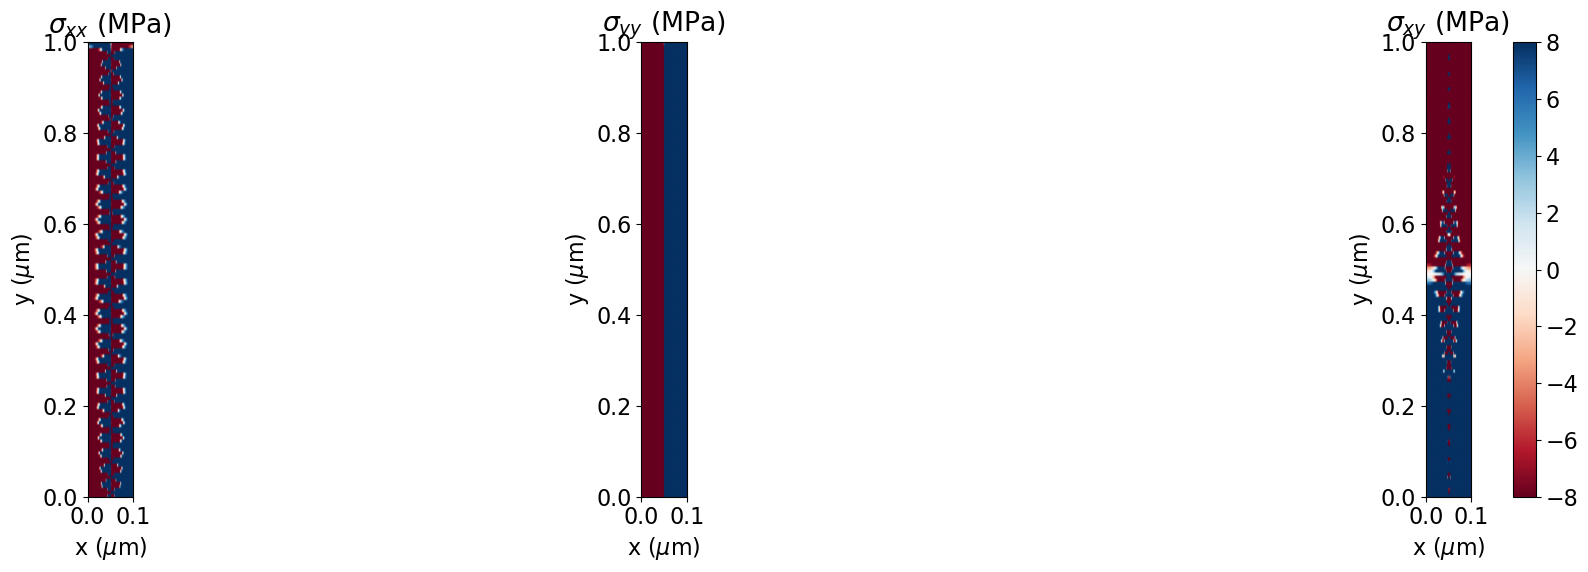

Initial force (max, median): 0.07120862498100267 0.019084269126556967
Initial configuration, Ntot: 29
box size: 0.1 micron x  1.0 micron
total dislocation density:  290.0 /micron^2
Final force (max, median): 0.44555021515778925 2.6724793416647686e-05
[0.         0.0010348  0.0069145  0.00922409 0.01592335 0.02182538
 0.0301061  0.03985257 0.0511601  0.06405419 0.0785758  0.09477607
 0.1127165  0.1324701  0.15412321 0.17777803 0.2035562  0.23160347
 0.26209631 0.29525107 0.33133739 0.37069829 0.41378158 0.46119199
 0.51378351 0.5728395  0.64047348 0.72072636 0.82398243]


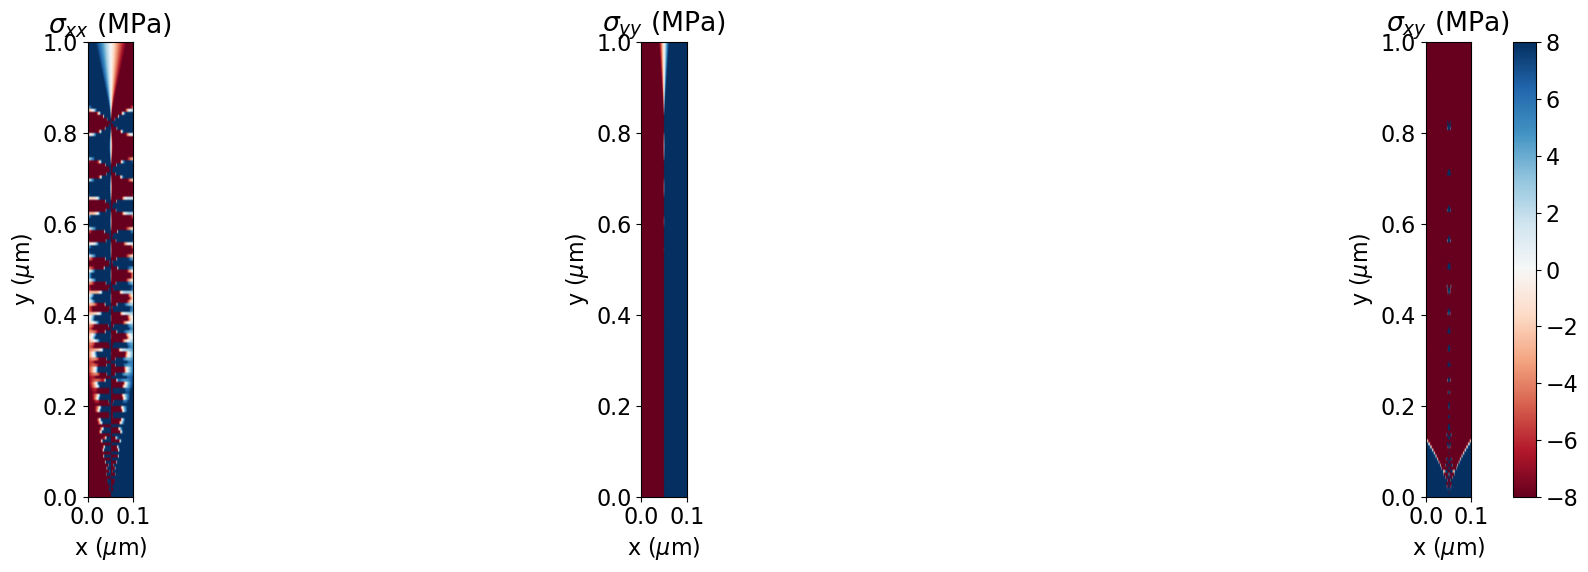

In [43]:
#box geometry
LX = lgb            # box dimension in x-direction
LY = gs             # box dimension in y-direction
bc = 'fixed'            # set boundary conditions: 'fixed' or 'pbc'

#define numerical parameters
dt0 = 0.02           # sim_time step

#define dislocations
Ntot = int(np.pi*(1-nu)*gs*tau0/(mu*b0)) # total number of dislocations
Nmob = Ntot  # number of mobile dislocations
dsl = dd.Dislocations(Ntot, Nmob, 0.5*np.pi, C, b0, LX=LX, LY=LY, bc=bc, f0=f0) 
for i in range(Ntot):
    dsl.xpos[i] = LX*0.5
    dsl.ypos[i] = gs * (i+0.2) / Ntot

dsl.plot_stress(show_arrows=False) # plot initial configuration
fsp = dsl.calc_force()[1]
print('Initial force (max, median):', np.max(np.abs(fsp)), np.median(np.abs(fsp)))
print('Initial configuration, Ntot:',dsl.Ntot)
print('box size:',LX,'micron x ',LY,'micron')
print('total dislocation density: ',dsl.rho,'/micron^2')

#relax dislocation configuration, i.e. move dislocations to force equilibrium
for i in range(5000):
    fsp, dt = dsl.move_disl(-tau0, Ntot, "viscous", dt0)
print('Final force (max, median):', np.max(np.abs(fsp)), np.median(np.abs(fsp)))
print(dsl.ypos[:Ntot])
dsl.plot_stress(show_arrows=False)

Simulation with N_gbn=25, grain_size=1.0, dtmax=2441.4062499999995
Set drag: 500.0
Set nu: 0.3
Set mu: 44000.0
Set B: 0.00025
 Conducting simulation with Npu preexisting dislocations: Npu =          27
 and Nabs absorbed dislocations: Nabs =           2
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        150.00000000000000        1.0000000000000000       0.10000000000000001               25
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)       50000  0.29580581753620300        1.3069153093801859E-002   8.2531357915938529E-009   5.0089982176666022E-004          27           2  0.82397033036354717     
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)      100000  0.38438466989564879        3.0251582982253885E-002   6.3513800466815760E-009   5.0198699722842955E-004          27           2  0.82395443494574383     
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)      150000  0.51812590557432847        5.11961156

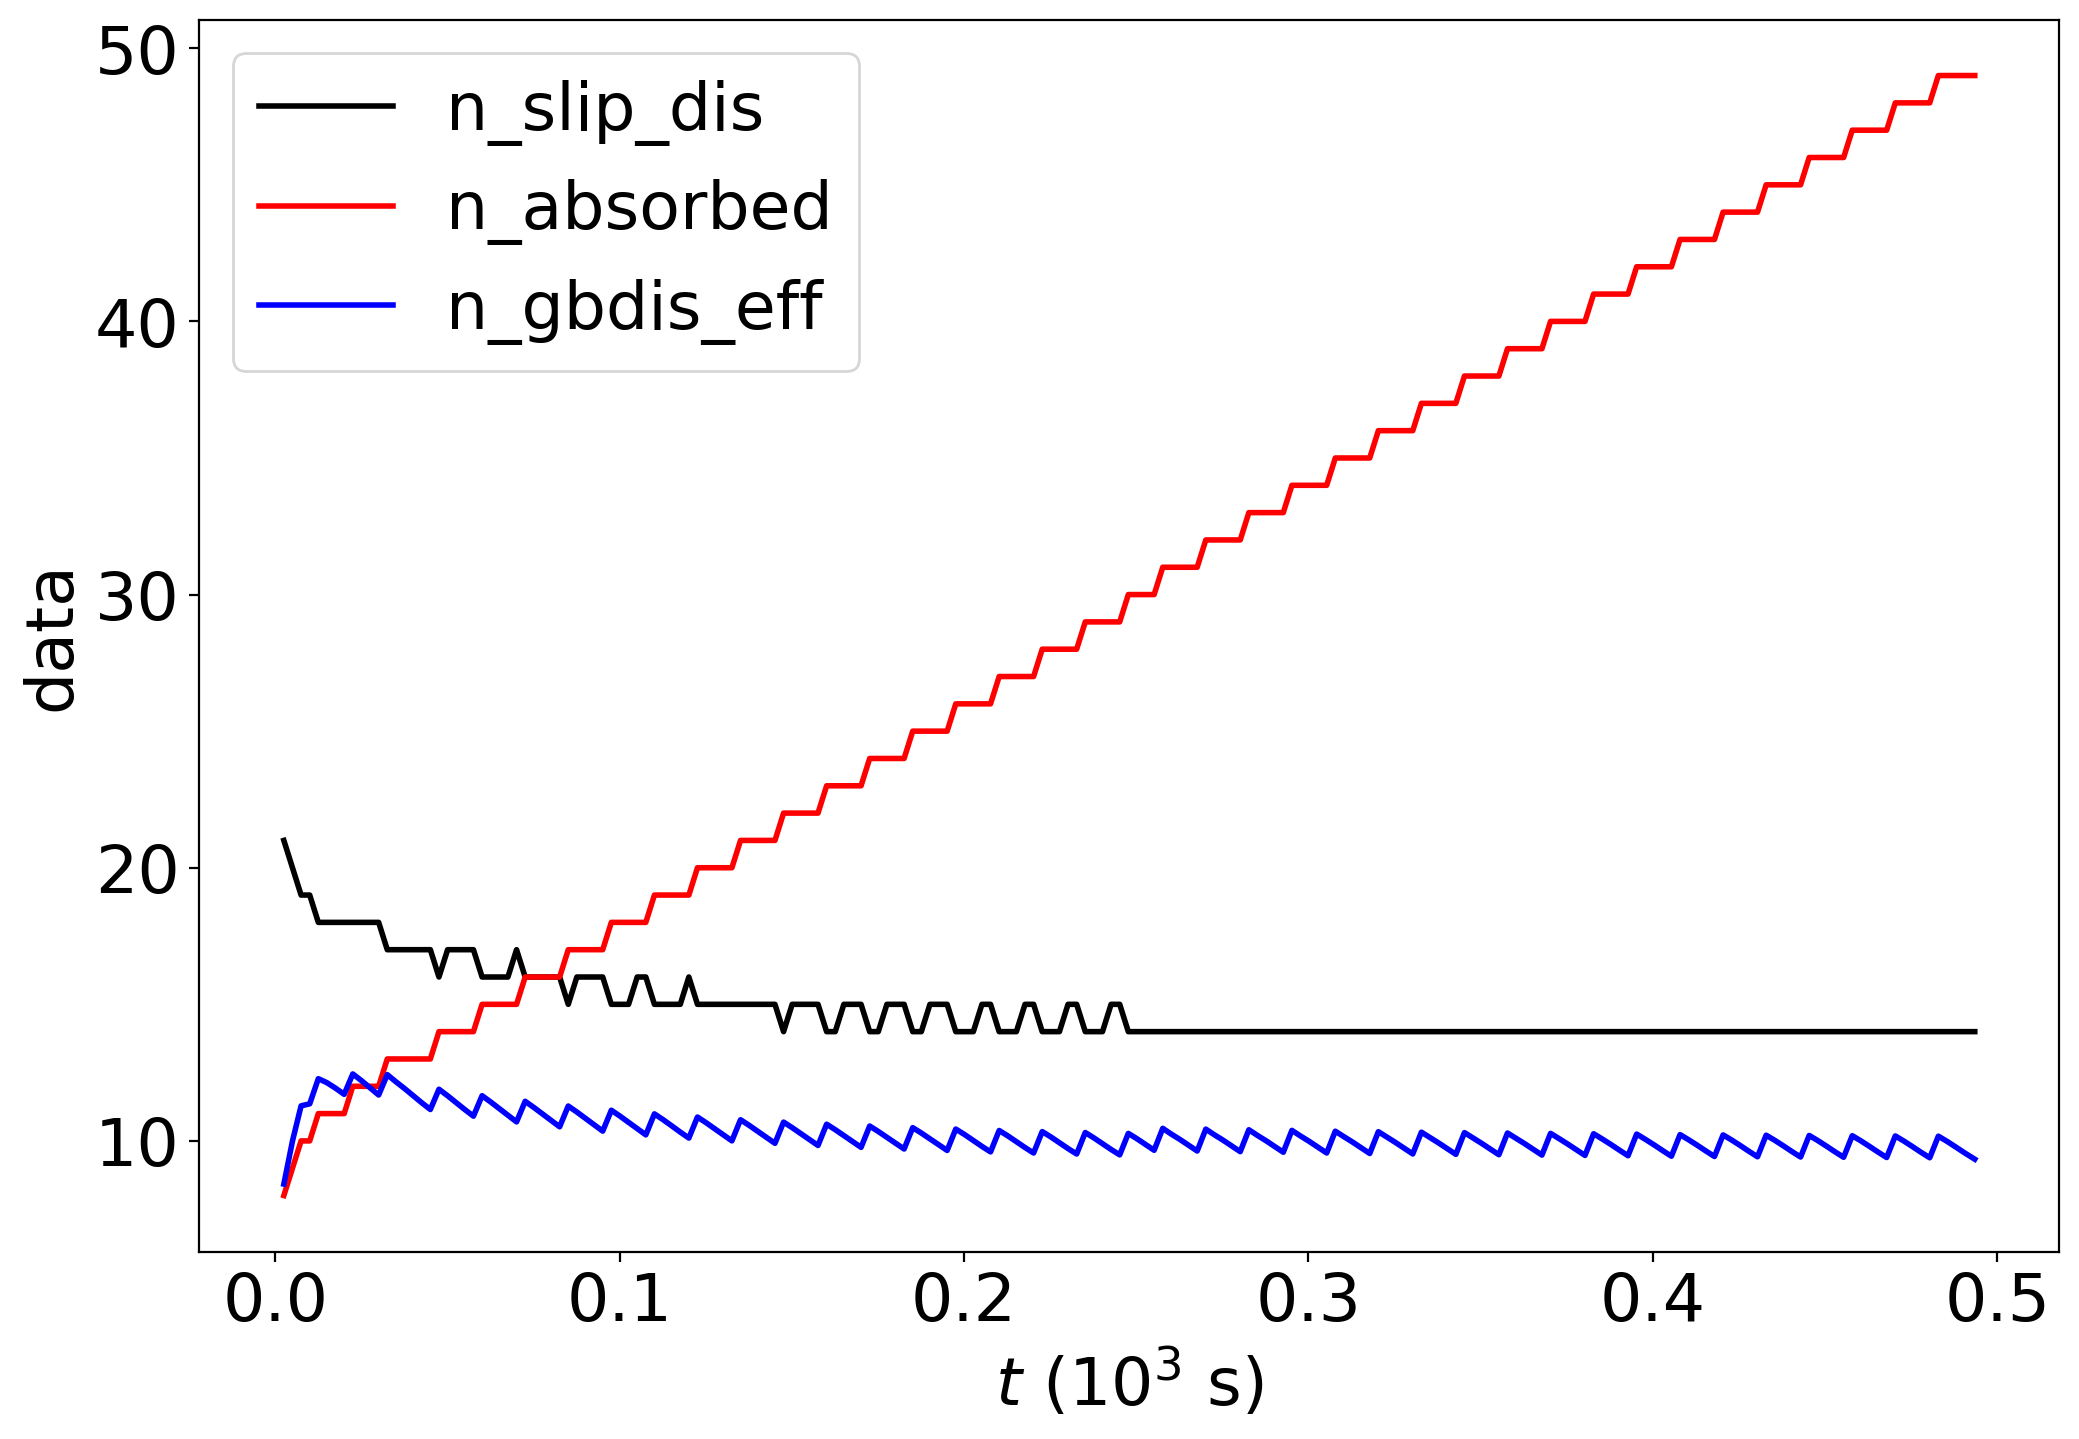

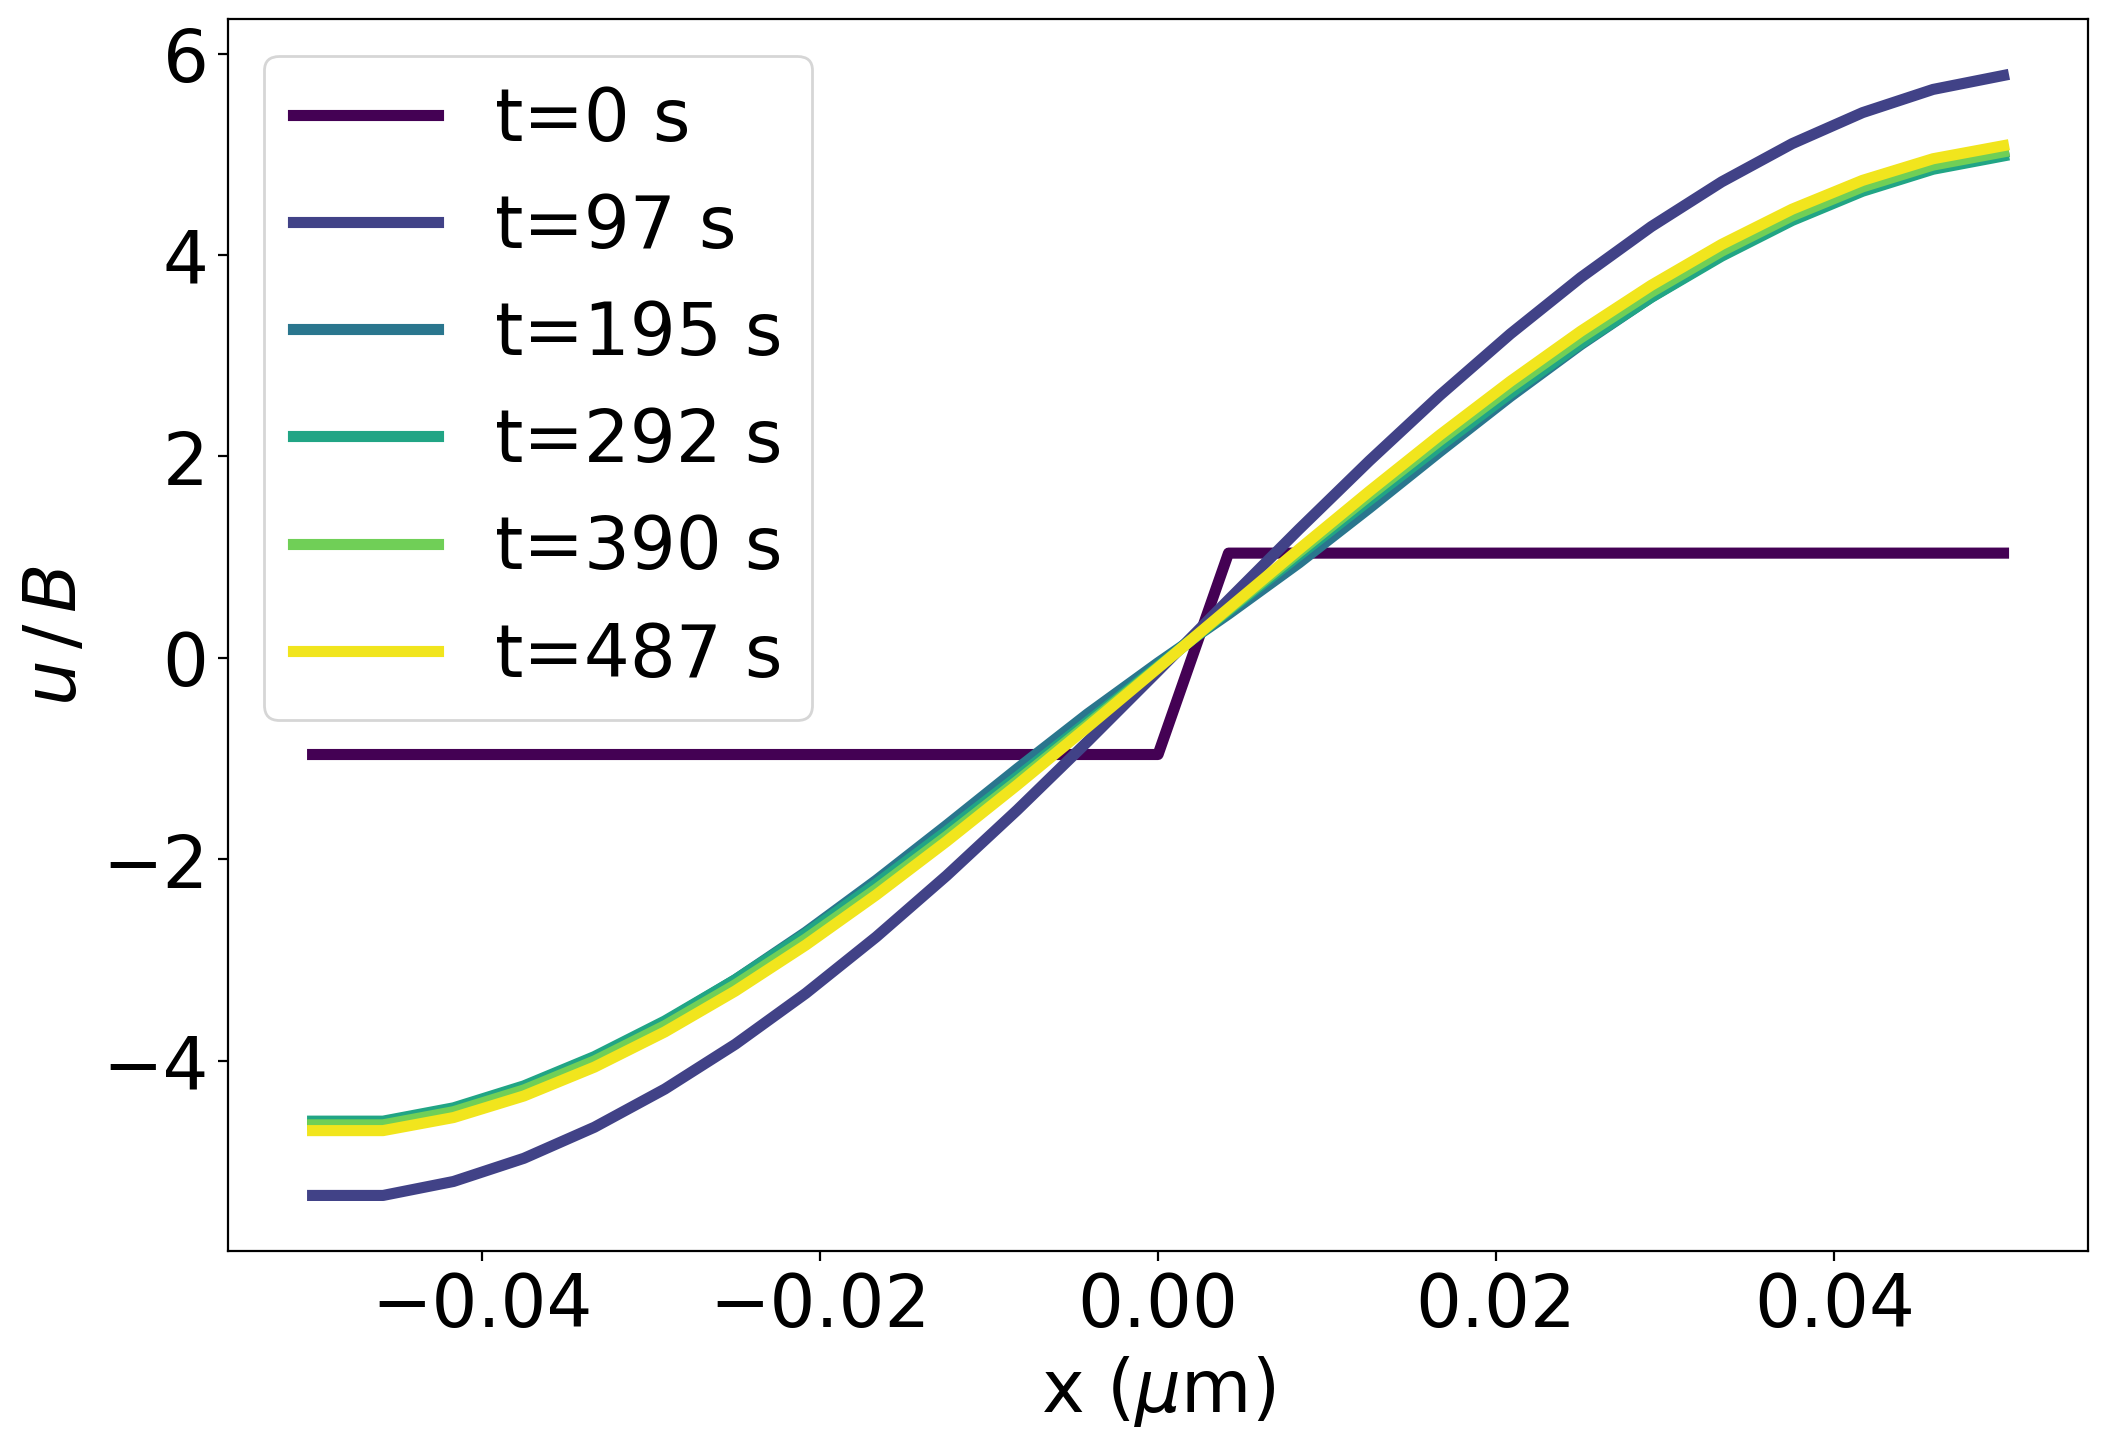

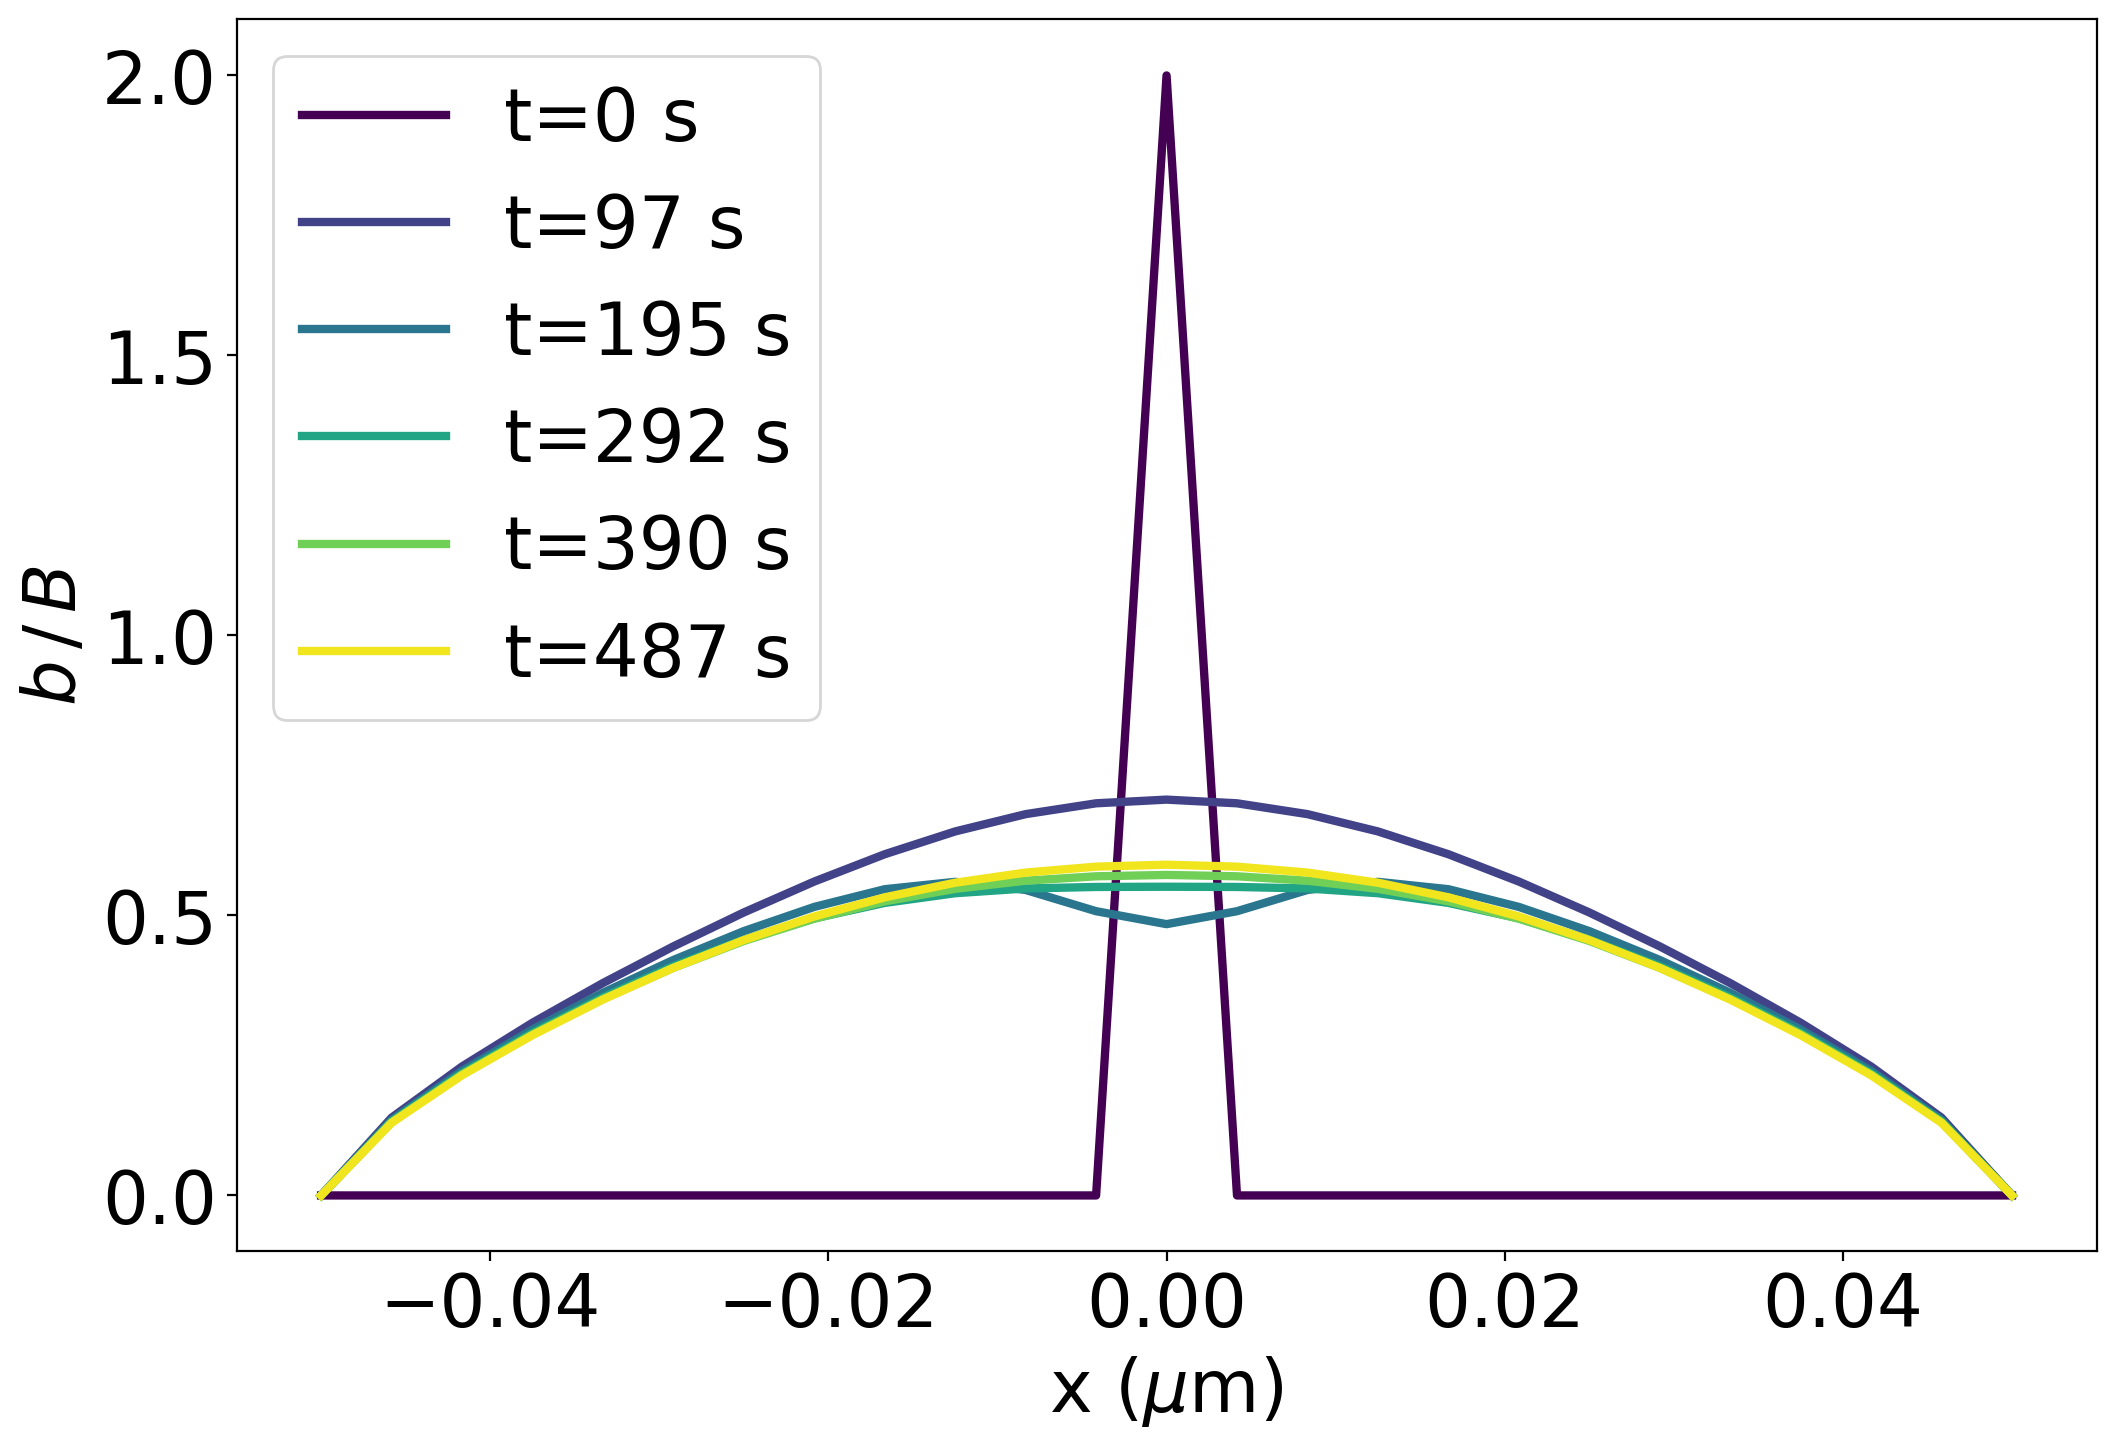

In [47]:
# run special simulation with 1 immobile dislocation in pile up with drag > 1.e5
print(f"Simulation with N_gbn={ngbn}, grain_size={gs}, dtmax={dtmax}")
gbdd = dd.GB_dislocations(temp=temp, tau0=tau0,
                   Ngbn=ngbn, len_gb_seg=lgb, grain_size=gs,
                   tfin=tfin, niter=niter,
                   dtmax=dtmax, drag=drag,
                   nu=nu, mu=mu, B=b0,
                   screenout=True)
gbdd.run_sim(pudis=dsl.ypos.copy())
#gbdd.save_hdf5(f"pu1im_T{int(temp)}_H{int(gs*10)}_L{int(lgb*10)}.h5")
gbdd.plot_time_series(['n_slip_dis', 'n_absorbed', 'n_gbdis_eff'])
#gbdd.plot_time_series('plastic_slip', fs=26, lw=3)
gbdd.plot_field('displacement', fs=26, lw=4, nplot=5,
#                file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf"
               )
gbdd.plot_field('bfield', fs=26, lw=3, nplot=5,
#                file=f"tau{int(tau0)}_T{int(temp)}_D{int(gs*10)}.pdf"
               )

In [48]:
print(dsl.ypos[:Ntot])
print(gbdd.pu_dis['position'][gbdd.nout-1, :])

[0.         0.0010348  0.0069145  0.00922409 0.01592335 0.02182538
 0.0301061  0.03985257 0.0511601  0.06405419 0.0785758  0.09477607
 0.1127165  0.1324701  0.15412321 0.17777803 0.2035562  0.23160347
 0.26209631 0.29525107 0.33133739 0.37069829 0.41378158 0.46119199
 0.51378351 0.5728395  0.64047348 0.72072636 0.82398243]
[0.00372133 0.06168037 0.09731323 0.13399836 0.17417838 0.21931444
 0.27085008 0.33052509 0.40047181 0.48278377 0.57817472 0.68469249
 0.79767732 0.90939647 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]


In [50]:
gbdd.nout

199

Number of dislocations: 14, Simulation time: 475.40042321719864


/opt/miniconda3/envs/pylabdd/lib/python3.12/site-packages/pylabdd/dislocations.py:190: RuntimeWarning: invalid value encountered in divide
  return self.C * X_arr * (hx - hy) / (hh * hh)


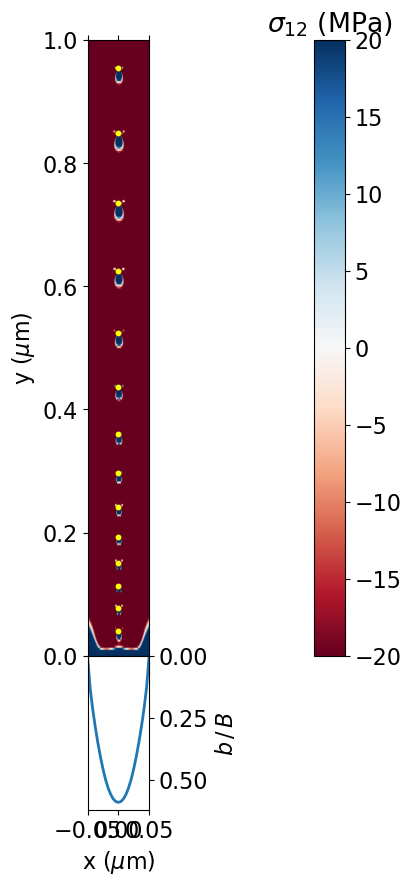

In [51]:
it = 190
plt.rcParams["font.size"] = 16
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
assert npu == gbdd.glob_data['n_slip_dis'][it]
ngbn = gbdd.Ngbn
Nc = int((ngbn+1)/2) - 1
gbdx = gbdd.Dgp/(ngbn-1)
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
print(f"Number of dislocations: {npu}, Simulation time: {gbdd.sim_time[it]*1.e-6}")

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
plot_stress_bfield(cutoff=20, fs=(14.2,10), 
                   file=f"sigpu1im_T{int(gbdd.temp)}_D{int(gbdd.D2*10)}_L{int(gbdd.Dgp*10)}.pdf"
                  )


In [ ]:
plt.plot(gbdd.sim_time, gbdd.pu_dis['force'], 'b-')
plt.show()

In [ ]:
gbdd.nout